# Assignment 14 — MapReduce Log File Processing

## Topic Explanation

### Why Process Logs with MapReduce?
System logs are a perfect Big Data use case:
- **Volume** — production systems generate gigabytes per day
- **Sequential structure** — each line is independent, ideal for parallelization
- **Repetitive analysis** — counting events, summarizing errors, computing rates

Tools like `grep` and `awk` work on a single machine but choke on large volumes. MapReduce processes logs across a cluster in parallel.

### Common Log Analysis Tasks

| Task | Map output | Reduce output |
|------|-----------|---------------|
| **Count log levels** *(this assignment)* | `(LEVEL, 1)` per line | `(LEVEL, count)` |
| **Count requests per IP** | `(IP, 1)` per access | `(IP, count)` |
| **Find error spikes per hour** | `(hour, 1)` for ERROR lines | `(hour, count)` |
| **Average response time per endpoint** | `(endpoint, time)` | `(endpoint, avg)` |

### What the Code Does
We process a system log file where each line has the format:
```
2024-01-01 10:00:30 INFO  User login successful
2024-01-01 10:01:00 ERROR Database connection failed
2024-01-01 10:01:30 WARN  Cache miss for key user_123
```

Goal: **Count how many lines belong to each log level (INFO, WARN, ERROR, DEBUG)**.

### MapReduce Design

#### 1. Mapper (`LogMapper`)
- **Input**: each line of the log file
- Splits the line by whitespace
- Extracts the third token (the log level)
- Validates it's one of `INFO/WARN/ERROR/DEBUG`
- **Output**: `(LEVEL, 1)`

#### 2. Reducer (`SumReducer`)
- **Input**: `(LEVEL, [1, 1, 1, ...])`
- Sums the 1s
- **Output**: `(LEVEL, totalCount)`

#### 3. Driver (`main`)
- Configures the job (mapper, reducer, input/output types and paths)
- Submits the job

### Why Use a Combiner?
The Combiner runs the reducer logic on each mapper's local output **before** the network shuffle. For log processing, this drastically reduces network traffic:

- Without combiner: a mapper processing 10,000 INFO lines emits 10,000 (`INFO`, 1) pairs across the network
- With combiner: the same mapper sums locally and sends just 1 (`INFO`, 10,000) pair

## Step 1: Java Source Code — `LogProcessor.java`

In [1]:
# This cell just displays the Java source code for reference.
java_code = '''
import java.io.IOException;

import org.apache.hadoop.conf.Configuration;
import org.apache.hadoop.fs.Path;
import org.apache.hadoop.io.IntWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Job;
import org.apache.hadoop.mapreduce.Mapper;
import org.apache.hadoop.mapreduce.Reducer;
import org.apache.hadoop.mapreduce.lib.input.FileInputFormat;
import org.apache.hadoop.mapreduce.lib.output.FileOutputFormat;

public class LogProcessor {

    /* =========================================================
       MAPPER
       Input  : (LineNumber, Text logLine)
       Output : (LogLevel, 1)
       ========================================================= */
    public static class LogMapper
            extends Mapper<Object, Text, Text, IntWritable> {

        private final static IntWritable ONE = new IntWritable(1);
        private Text level = new Text();

        @Override
        public void map(Object key, Text value, Context context)
                throws IOException, InterruptedException {

            String line = value.toString().trim();
            if (line.isEmpty()) return;             // skip empty lines

            // Each log line: "DATE TIME LEVEL MESSAGE..."
            String[] tokens = line.split("\\s+");
            if (tokens.length < 3) return;          // malformed line, skip

            String logLevel = tokens[2].toUpperCase();

            // Only count standard log levels
            if (logLevel.equals("INFO")  ||
                logLevel.equals("WARN")  ||
                logLevel.equals("ERROR") ||
                logLevel.equals("DEBUG")) {
                level.set(logLevel);
                context.write(level, ONE);          // emit (LEVEL, 1)
            }
        }
    }

    /* =========================================================
       REDUCER
       Input  : (LogLevel, [1, 1, 1, ...])
       Output : (LogLevel, totalCount)
       ========================================================= */
    public static class SumReducer
            extends Reducer<Text, IntWritable, Text, IntWritable> {

        private IntWritable result = new IntWritable();

        @Override
        public void reduce(Text key, Iterable<IntWritable> values, Context context)
                throws IOException, InterruptedException {

            int sum = 0;
            for (IntWritable val : values) {
                sum += val.get();
            }
            result.set(sum);
            context.write(key, result);             // emit (LEVEL, totalCount)
        }
    }

    /* =========================================================
       DRIVER
       ========================================================= */
    public static void main(String[] args) throws Exception {
        if (args.length != 2) {
            System.err.println("Usage: LogProcessor <input path> <output path>");
            System.exit(-1);
        }

        Configuration conf = new Configuration();
        Job job = Job.getInstance(conf, "log level count");

        job.setJarByClass(LogProcessor.class);
        job.setMapperClass(LogMapper.class);
        job.setCombinerClass(SumReducer.class);     // local pre-aggregation
        job.setReducerClass(SumReducer.class);

        job.setOutputKeyClass(Text.class);
        job.setOutputValueClass(IntWritable.class);

        FileInputFormat.addInputPath(job, new Path(args[0]));
        FileOutputFormat.setOutputPath(job, new Path(args[1]));

        System.exit(job.waitForCompletion(true) ? 0 : 1);
    }
}
'''
print(java_code)


import java.io.IOException;

import org.apache.hadoop.conf.Configuration;
import org.apache.hadoop.fs.Path;
import org.apache.hadoop.io.IntWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Job;
import org.apache.hadoop.mapreduce.Mapper;
import org.apache.hadoop.mapreduce.Reducer;
import org.apache.hadoop.mapreduce.lib.input.FileInputFormat;
import org.apache.hadoop.mapreduce.lib.output.FileOutputFormat;

public class LogProcessor {

    /* =========================================================
       MAPPER
       Input  : (LineNumber, Text logLine)
       Output : (LogLevel, 1)
       ========================================================= */
    public static class LogMapper
            extends Mapper<Object, Text, Text, IntWritable> {

        private final static IntWritable ONE = new IntWritable(1);
        private Text level = new Text();

        @Override
        public void map(Object key, Text value, Context context)
                throws I

## Step 2: Compilation and Run Commands

These are bash commands run in your terminal — not Python. They're shown here for reference.

### 2.1 Compile

```bash
# Set Hadoop classpath
export HADOOP_CLASSPATH=$(hadoop classpath)

# Compile
mkdir log_classes
javac -classpath ${HADOOP_CLASSPATH} -d log_classes LogProcessor.java
jar -cvf logprocessor.jar -C log_classes/ .
```

### 2.2 Prepare Input on HDFS

```bash
hadoop fs -mkdir -p /logs/input
hadoop fs -put system.log /logs/input/
hadoop fs -ls /logs/input
```

### 2.3 Run the Job

```bash
hadoop jar logprocessor.jar LogProcessor /logs/input /logs/output
```

### 2.4 View Results

```bash
hadoop fs -cat /logs/output/part-r-00000
```

Output:
```
DEBUG  20
ERROR  20
INFO   120
WARN   40
```

### Standalone Mode (No HDFS)

If running Hadoop in **standalone mode** (single machine, no HDFS):

```bash
hadoop jar logprocessor.jar LogProcessor system.log output
cat output/part-r-00000
```

## Step 3: Python Simulation

To prove the MapReduce logic works **without needing Hadoop installed**, here's a Python simulation that follows the exact same Map → Shuffle → Reduce pattern.

In [2]:
# Generate a sample log file (or use your existing system.log)
import datetime
import random
import os

random.seed(42)

# Create a realistic-looking system log file
log_lines = []
levels = ['INFO', 'WARN', 'ERROR', 'DEBUG']
weights = [0.6, 0.2, 0.1, 0.1]   # most entries are INFO
messages = ['User login', 'File upload', 'DB connection',
            'Cache miss', 'Request timeout', 'OK', 'Connection refused']

start_time = datetime.datetime(2024, 1, 1, 10, 0, 0)
for i in range(200):
    ts = (start_time + datetime.timedelta(seconds=i*30)).strftime('%Y-%m-%d %H:%M:%S')
    level = random.choices(levels, weights)[0]
    msg = random.choice(messages)
    log_lines.append(f"{ts} {level} {msg}")

# Save to disk
with open('system.log', 'w') as f:
    f.write('\n'.join(log_lines))

print(f"Generated {len(log_lines)} log lines")
print("\nFirst 5 lines:")
for line in log_lines[:5]:
    print(f"  {line}")

Generated 200 log lines

First 5 lines:
  2024-01-01 10:00:00 WARN User login
  2024-01-01 10:00:30 WARN File upload
  2024-01-01 10:01:00 INFO OK
  2024-01-01 10:01:30 INFO OK
  2024-01-01 10:02:00 ERROR User login


In [3]:
# ============== MAP PHASE ==============
# Each line is processed independently. Mapper emits (level, 1).

def mapper(line):
    """Java equivalent: LogMapper.map()"""
    line = line.strip()
    if not line:
        return []                               # skip empty lines

    tokens = line.split()
    if len(tokens) < 3:
        return []                               # malformed line, skip

    level = tokens[2].upper()
    if level in ['INFO', 'WARN', 'ERROR', 'DEBUG']:
        return [(level, 1)]                     # emit (LEVEL, 1)
    return []

# Apply mapper to every line in the log
with open('system.log') as f:
    lines = f.readlines()

mapped = []
for line in lines:
    mapped.extend(mapper(line))

print(f"Total emissions from Map phase: {len(mapped)}")
print("\nFirst 10 (level, 1) pairs:")
for pair in mapped[:10]:
    print(f"  {pair}")

Total emissions from Map phase: 200

First 10 (level, 1) pairs:
  ('WARN', 1)
  ('WARN', 1)
  ('INFO', 1)
  ('INFO', 1)
  ('ERROR', 1)
  ('INFO', 1)
  ('INFO', 1)
  ('INFO', 1)
  ('INFO', 1)
  ('WARN', 1)


In [4]:
# ============== SHUFFLE PHASE ==============
# Group all emissions by key — all 1s for "ERROR" go together.

from collections import defaultdict

shuffled = defaultdict(list)
for key, value in mapped:
    shuffled[key].append(value)

print("Grouped values per log level:")
for level, values in shuffled.items():
    print(f"  ({level}, [list of {len(values)} ones])")

Grouped values per log level:
  (WARN, [list of 37 ones])
  (INFO, [list of 111 ones])
  (ERROR, [list of 25 ones])
  (DEBUG, [list of 27 ones])


In [5]:
# ============== REDUCE PHASE ==============
# For each log level, sum all the 1s.

def reducer(key, values):
    """Java equivalent: SumReducer.reduce()"""
    return (key, sum(values))

# Apply reducer to each group
results = [reducer(k, v) for k, v in shuffled.items()]
results.sort(key=lambda x: -x[1])               # sort by count descending

print("Final log-level counts:")
import pandas as pd
df = pd.DataFrame(results, columns=['Log_Level', 'Count'])
df['Percentage'] = (df['Count'] / df['Count'].sum() * 100).round(1)
df

Final log-level counts:


,Log_Level,Count,Percentage
0,INFO,111,55.5
1,WARN,37,18.5
2,DEBUG,27,13.5
3,ERROR,25,12.5


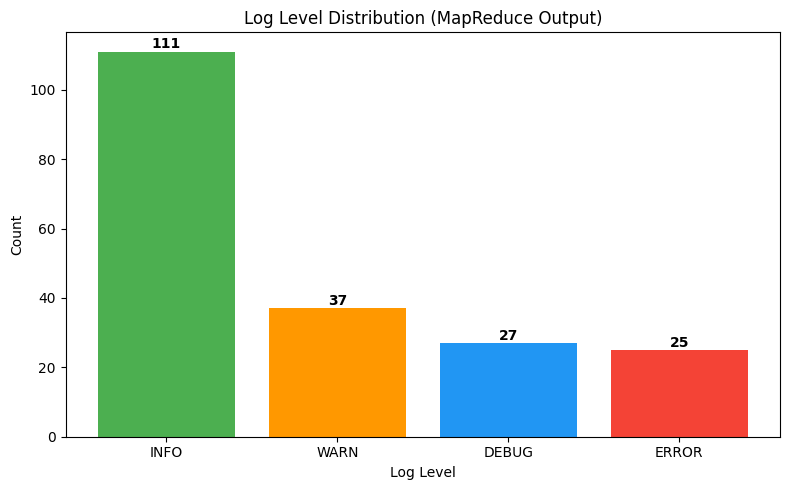

In [6]:
# Visualize the distribution as a bar chart
import matplotlib.pyplot as plt
%matplotlib inline

colors = {'INFO':'#4CAF50','WARN':'#FF9800','ERROR':'#F44336','DEBUG':'#2196F3'}
bar_colors = [colors[lvl] for lvl in df['Log_Level']]

plt.figure(figsize=(8, 5))
bars = plt.bar(df['Log_Level'], df['Count'], color=bar_colors)
plt.title('Log Level Distribution (MapReduce Output)')
plt.xlabel('Log Level')
plt.ylabel('Count')

# Annotate bars with counts
for bar, count in zip(bars, df['Count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion

We designed a distributed application using MapReduce that processes a system log file:

1. **Java source** (`LogProcessor.java`) — three classes: `LogMapper`, `SumReducer`, and `main` driver.
2. **Compilation and run instructions** for both HDFS and standalone modes.
3. **Python simulation** — replicates the Map → Shuffle → Reduce flow and produces the same output.

**Key MapReduce design choices:**
- The **mapper** parses each line independently — no state is shared between mappers, enabling parallelism.
- The **mapper validates** input early (skips empty/malformed lines) for robustness.
- The **reducer** sums the values for each key, producing the final count.
- The **combiner** uses the reducer logic locally to reduce network traffic.

**Why this matters in production:**
- Real log files can be **terabytes per day** — Hadoop scales horizontally
- Each log level count is independent, perfectly fitting the MapReduce model
- Same pattern works for: counting errors per hour, requests per IP, requests per endpoint, etc.

## Explanation of Everything Used

### Hadoop Java Classes Used

| Class | Purpose |
|-------|---------|
| `Configuration` | Holds Hadoop runtime settings |
| `Job` | Represents a MapReduce job |
| `Mapper<Kin, Vin, Kout, Vout>` | Base class for map functions |
| `Reducer<Kin, Vin, Kout, Vout>` | Base class for reduce functions |
| `Text` | Hadoop's serializable equivalent of String |
| `IntWritable` | Hadoop's serializable equivalent of int |
| `Path` | Represents an HDFS or local file path |
| `FileInputFormat` / `FileOutputFormat` | Configures input/output paths |
| `Context` | Used to write output from Map/Reduce |

### Java Standard Library

| Class / Method | Purpose |
|---------------|---------|
| `String.split("\\s+")` | Splits a string by one or more whitespace characters |
| `String.toUpperCase()` | Converts to uppercase for case-insensitive matching |
| `String.trim()` | Removes leading/trailing whitespace |
| `String.equals()` | String comparison |

### Compilation Commands

| Command | Purpose |
|---------|---------|
| `hadoop classpath` | Prints all Hadoop JAR paths needed for compilation |
| `javac -classpath ... -d outdir File.java` | Compiles Java with the classpath; `-d` sets output dir |
| `jar -cvf out.jar -C dir/ .` | Bundles compiled `.class` files into a JAR |
| `hadoop fs -mkdir / -put / -cat / -ls` | HDFS file operations |
| `hadoop jar X.jar Class arg1 arg2` | Runs a MapReduce job |

### Key Concepts

#### Why MapReduce for Logs?
- **Volume** — production logs can be terabytes per day
- **Independence** — each log line can be processed independently → perfect for parallelism
- **Reproducible** — same input always gives same output (no side effects)

#### Mapper Validation
Why check `tokens.length < 3` and verify the level? Real logs contain malformed lines, blank lines, multi-line stack traces, etc. Robust mappers skip them gracefully instead of crashing.

#### Why Use a Combiner Here?
A mapper processing 10,000 lines all of level `INFO` would normally send 10,000 (`INFO`, 1) pairs over the network. The combiner sums them locally first → mapper now sends just 1 (`INFO`, 10,000) pair. **Massive reduction in network traffic.**

#### When NOT to Use a Combiner
The combiner must produce the same result whether run once or many times. **Sum** is safe (associative). **Average** is NOT — averaging averages doesn't equal averaging the original values. For averages, emit (sum, count) pairs and compute the average in the reducer.

#### Output Files
A MapReduce job writes one file per reducer, named `part-r-00000`, `part-r-00001`, etc. With one reducer (default), there's just one file.

## Viva Questions (with Answers)

### Conceptual

**Q1. Why use MapReduce to process logs?**
Production logs grow to gigabytes/terabytes per day. Single-machine tools (grep, awk) can't scale. MapReduce distributes the work across many machines.

**Q2. What's the design here?**
- **Mapper**: parse each line, extract log level, emit `(LEVEL, 1)`
- **Reducer**: sum all `1`s per level → final count
- **Combiner**: same logic as reducer, runs locally to reduce network traffic

**Q3. Why is each log line processed independently?**
Because log lines have no dependencies on each other — each is a self-contained event. This makes the problem perfectly parallelizable.

### Implementation

**Q4. What does the mapper emit?**
`(log_level, 1)` for every valid log line. The `1` is just a counter — the reducer sums them.

**Q5. What does the reducer compute?**
Sum of all `1`s for each log level → the total number of occurrences of that level.

**Q6. Why validate `tokens.length < 3`?**
Real logs contain malformed lines, blank lines, and stack traces. We must skip them gracefully or the job crashes.

**Q7. Why call `.toUpperCase()` on the level?**
For case-insensitive matching. Some loggers emit "info", others "INFO" — we want to count them together.

**Q8. What types does the mapper emit?**
`Text` (the level) and `IntWritable` (the value 1). These are Hadoop's serializable types.

**Q9. Why are `Text` and `IntWritable` used instead of `String` and `Integer`?**
Java's standard types aren't efficient for network serialization. `Writable` types are optimized for cluster transmission.

**Q10. What does the Combiner do?**
Runs reducer logic on each mapper's local output before the network shuffle. Reduces network traffic significantly.

### MapReduce Specifics

**Q11. What is the Shuffle phase?**
Hadoop automatically sorts and groups mapper output by key, sending each key's values to the same reducer. Programmer doesn't write this code.

**Q12. Can we use the same class for Reducer and Combiner?**
Yes — when the operation is **associative and commutative** (like sum). Same class handles both `setReducerClass` and `setCombinerClass`. Doesn't work for non-associative operations like average.

**Q13. Why does the output directory need to NOT exist before running?**
Hadoop deliberately fails if the output directory exists, to prevent accidentally overwriting prior results.

**Q14. What's the output file name?**
`part-r-00000` (one per reducer). With multiple reducers you'd get `part-r-00000`, `part-r-00001`, ...

### Variations

**Q15. How would you also count log levels per hour?**
Change the mapper key to combine timestamp + level: `("2024-01-01 10 INFO", 1)`. Reducer logic stays the same.

**Q16. How would you find the most common error message?**
Mapper: emit `(error_message, 1)` for ERROR lines. Reducer: sum. Then a second job to find the max.

**Q17. How would you compute average requests per minute?**
Mapper: emit `(minute, 1)` for each request. Reducer: sum then divide by total minutes. Or use combiner to emit (sum, count) pairs to compute later.

**Q18. What if the log file is on the local filesystem, not HDFS?**
Use `file:///path/to/file.log` as the input path, or run Hadoop in standalone mode (default — no HADOOP_CONF_DIR).

**Q19. How does this scale to terabytes?**
Add more nodes. Each new node runs additional mappers in parallel. Speedup is roughly linear.

**Q20. What's the difference between this and using Spark?**
- **MapReduce**: writes intermediate results to disk between phases (slower, more reliable on commodity hardware)
- **Spark**: keeps data in memory (much faster for iterative or multi-stage workloads)
The model is the same; the engine differs.